In [49]:
from pychrtrace import ImageHandler, Tracer, SpotPicker, NucDetector
from pychrtrace import image_processing_functions as ip
from pychrtrace.gaussfit import fitSymmetricGaussian3D as fit_3D
import dask.array as da
import dask
import napari
import numpy as np
import scipy.ndimage as ndi
import pandas as pd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
path = r'M:\ChromatinTeam\Images_processing\2021-03-05_Exp006_KSB_elyra_telomer_lowMWDS\2E'
nuc_ch = 1
spot_ch = 0
ds=2
thresh=20
z_low = 8

In [51]:
imgs, pos = ip.images_to_dask(path, ['.czi', 'DE_1'])
n = len(pos)

Loading files to dask array: 
[=========] 100.0%
 Loaded images of shape:  (10, 1, 2, 40, 1280, 1280)
Found positions  ['W0001', 'W0002', 'W0003', 'W0004', 'W0005', 'W0006', 'W0007', 'W0008', 'W0009', 'W0010']


In [52]:
nucs = [da.max(imgs[pos,0,nuc_ch,::ds,::ds,::ds], axis=0).compute() for pos in range(imgs.shape[0])]
nuc_masks = ip.nuc_segmentation(nucs, diameter=75)
nucs = np.stack(nucs)
nuc_masks = [ndi.morphology.grey_dilation(img, 5) for img in nuc_masks]
nuc_masks = np.stack(nuc_masks)

  0%|          | 0/10 [00:00<?, ?it/s]>>>> using CPU
Running test snippet to check if MKL-DNN working
see https://pytorch.org/docs/stable/backends.html?highlight=mkl
** MKL version working - CPU version is sped up. **
processing 10 image(s)
100%|██████████| 10/10 [00:04<00:00,  2.50it/s]time spent: running network 2.15s; flow+mask computation 1.73
estimated masks for 10 image(s) in 4.12 sec
>>>> TOTAL TIME 4.12 sec



In [53]:
spot_imgs = np.vstack([imgs[pos,:,spot_ch,z_low::ds,::ds,::ds].compute() for pos in range(n)])

In [54]:
labels = [np.unique(nuc_masks[i]) for i in range(n)]
nuc_int = []
for i in range(n):
    for l in labels[i]:
        mask = nuc_masks[i] == l
        nuc_int.append(np.median(np.max(spot_imgs[i], axis=0)[mask]))
print(np.median(nuc_int))

230.0


In [55]:
spots, spot_segs = zip(*[ip.detect_spots(spot_imgs[i], thresh) for i in range(n)])
spots = [pos[['zc', 'yc',  'xc']].to_numpy() for pos in spots]
spot_segs = np.stack(spot_segs)
points = np.vstack([np.insert(spots[i], 0, [i]*spots[i].shape[0], axis=1) for i in range(n)])
in_nuc = np.array([nuc_masks[tuple(points[i,[0,2,3]].astype(int))] != 0 for i in range(points.shape[0])])
points = points[in_nuc,:]
points[:,1] = points[:,1]+z_low//ds

Found 239 spots.
Found 292 spots.
Found 316 spots.
Found 234 spots.
Found 262 spots.
Found 251 spots.
Found 244 spots.
Found 6 spots.
Found 271 spots.
Found 326 spots.


with napari.gui_qt():
    viewer = napari.view_image(spot_imgs)
    viewer.add_image(spot_segs)
    viewer.add_image(nucs)
    viewer.add_labels(nuc_masks)
    new_points = viewer.add_points(points, size=4,
                            edge_width=3,
                            edge_color='red',
                            face_color='transparent',)
points = new_points.data

points = np.round(points, decimals=0).astype(int)
zc = []
for i in range(points.shape[0]):
    zc.append(np.argmax(imgs[points[i,0], 0, spot_ch, 5::ds, points[i,1]*ds, points[i,2]*ds]))
zc = dask.compute(zc)[0]
points = np.insert(points, 1, zc, axis=1)

In [56]:
with napari.gui_qt():
    viewer = napari.view_image(imgs[:,0,nuc_ch, ::ds,::ds,::ds], colormap='blue', blending='additive')
    viewer.add_image(imgs[:,0,spot_ch, ::ds,::ds,::ds], blending='additive')
    new_points = viewer.add_points(points,
                        edge_width=3,
                        edge_color='red',
                        face_color='transparent',
                        n_dimensional=True,
                        size=np.array([1, 5, 5, 5]))

In [57]:
points=np.round(points).astype(int)
sspot_imgs = []
for i in range(points.shape[0]):
    zmin = points[i,1]*ds-5
    zmax = points[i,1]*ds+5
    ymin = points[i,2]*ds-8
    ymax = points[i,2]*ds+8
    xmin = points[i,3]*ds-8
    xmax = points[i,3]*ds+8
    sspot_imgs.append(imgs[points[i,0], 0, spot_ch, zmin:zmax, ymin:ymax, xmin:xmax])
sspot_imgs = dask.compute(sspot_imgs)[0]

In [58]:
fits = []
for i, img in enumerate(sspot_imgs):
    try:
        res = fit_3D(img, 1)[0]
    except ValueError:
        res = [np.nan]*7
    fits.append(res)

Fitting problem! 5 Number of calls to function has reached maxfev = 500.
Fitting problem! 5 Number of calls to function has reached maxfev = 500.
Fitting problem! 5 Number of calls to function has reached maxfev = 500.
Fitting problem! 5 Number of calls to function has reached maxfev = 500.
Fitting problem! 5 Number of calls to function has reached maxfev = 500.


In [59]:
fits = pd.DataFrame(fits, columns=['BG', 'A', 'zc_zoom', 'yc_zoom', 'xc_zoom', 'sigma_xy','sigma_z'])
fits['A_to_BG'] = fits['A']/fits['BG']
pos = pd.DataFrame(points, columns=['position', 'zc', 'yc', 'xc'])
fits = pd.concat([fits, pos], axis=1)
fits = fits[fits['BG']>0]
fits.to_csv(path+'_fits.csv')

<AxesSubplot:ylabel='A_to_BG'>

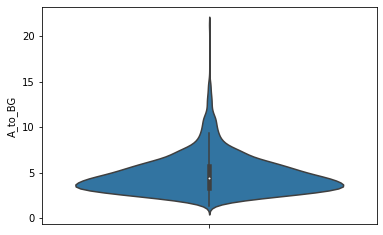

In [60]:
import seaborn as sns 
sns.violinplot(data=fits.query('sigma_xy >0 & sigma_z > 0 & BG > 0 & A>0 & sigma_xy < 3 & sigma_z < 3'), y='A_to_BG')